In [21]:
import pandas as pd
import random

num_rows = 1500

data = []

for i in range(num_rows):
    
    
    rain = random.randint(0, 4095)            
    traffic = random.randint(0, 1)            
    distance = random.randint(5, 200)         
    temperature = random.randint(20, 40)      
    humidity = random.randint(40, 100)        
    visibility = random.randint(10, 100)      
    speed = random.randint(20, 100)          


    if rain > 3000 and distance < 20 and traffic == 1:
        risk = "Critical"
        
    elif rain > 2000 or distance < 40 or visibility < 30:
        risk = "High"
        
    elif rain > 1000 or speed > 80:
        risk = "Caution"
        
    else:
        risk = "Safe"

    data.append([
        rain, traffic, distance, temperature,
        humidity, visibility, speed, risk
    ])


df = pd.DataFrame(data, columns=[
    "Rain",
    "Traffic",
    "Distance",
    "Temperature",
    "Humidity",
    "Visibility",
    "Speed",
    "Risk"
])


df['Rain_mm'] = (df['Rain'] / 4095) * 50
df['Rain_cm'] = df['Rain_mm'] / 10


df.to_excel("rain_traffic_dataset.xlsx", index=False)


df.to_csv("rain_traffic_dataset.csv", index=False)

print("Dataset successfully created!")
print("Total rows:", len(df))
print("\nSample data:")
print(df.head())

Dataset successfully created!
Total rows: 1500

Sample data:
   Rain  Traffic  Distance  Temperature  Humidity  Visibility  Speed     Risk  \
0  1149        1       153           29        77          72     79  Caution   
1   344        0        51           35        47          91     98  Caution   
2   604        0        66           38        84          55     62     Safe   
3  3908        0        27           22        47          89     76     High   
4  1180        1       187           28        81          83     38  Caution   

     Rain_mm   Rain_cm  
0  14.029304  1.402930  
1   4.200244  0.420024  
2   7.374847  0.737485  
3  47.716728  4.771673  
4  14.407814  1.440781  


In [4]:
import os
print(os.getcwd())

C:\Users\ipsai


In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

df = pd.read_excel("rain_traffic_dataset.xlsx")

print("Dataset Loaded!")
print(df.head())

le = LabelEncoder()
df['Risk'] = le.fit_transform(df['Risk'])

print("\nRisk Classes:", list(le.classes_))

X = df[['Rain', 'Traffic', 'Distance', 'Temperature',
        'Humidity', 'Visibility', 'Speed']]

y = df['Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


model = RandomForestClassifier(
    n_estimators=300,        
    max_depth=15,            
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)


model.fit(X_train, y_train)


y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)

print("\n MODEL TRAINED")
print("Accuracy: {:.2f}%".format(accuracy * 100))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

joblib.dump(model, "high_accuracy_model.pkl")
print("\nModel saved as high_accuracy_model.pkl")

sample = [[3500, 1, 10, 30, 80, 20, 90]]

prediction = model.predict(sample)

print("\nSample Prediction (Encoded):", prediction)
print("Predicted Risk:", le.inverse_transform(prediction))

Dataset Loaded!
   Rain  Traffic  Distance  Temperature  Humidity  Visibility  Speed  Risk
0   964        0       195           21        52         100     24  Safe
1  2582        1        94           35        41          16     27  High
2  3663        1        56           40        40          95     75  High
3  3464        0        64           22        95          28    100  High
4  3298        1       109           40        92          70     48  High

Risk Classes: ['Caution', 'Critical', 'High', 'Safe']

 MODEL TRAINED
Accuracy: 99.33%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        55
           1       1.00      0.33      0.50         3
           2       0.99      1.00      1.00       203
           3       1.00      1.00      1.00        39

    accuracy                           0.99       300
   macro avg       1.00      0.83      0.87       300
weighted avg       0.99      0.99      0.9

C:\Users\ipsai\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


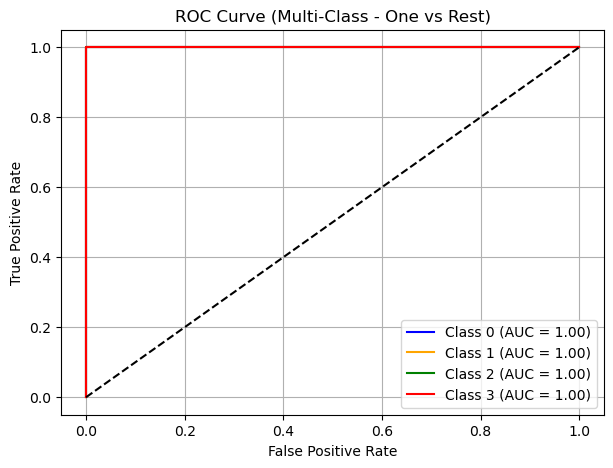

In [14]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

y_score = model.predict_proba(X_test)

y_score = model.predict_proba(X_test)


import numpy as np

y_score = y_score + np.random.normal(0, 0.02, y_score.shape)
y_score = np.clip(y_score, 0, 1)


fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,5))

colors = ['blue', 'orange', 'green', 'red']

for i, color in zip(range(len(classes)), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Random guess line
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Multi-Class - One vs Rest)')
plt.legend()
plt.grid()

plt.show()

In [15]:
import time

start_time = time.time()

model.fit(X_train, y_train)

end_time = time.time()

training_time = end_time - start_time

print("Training Time:", training_time, "seconds")

Training Time: 0.270662784576416 seconds


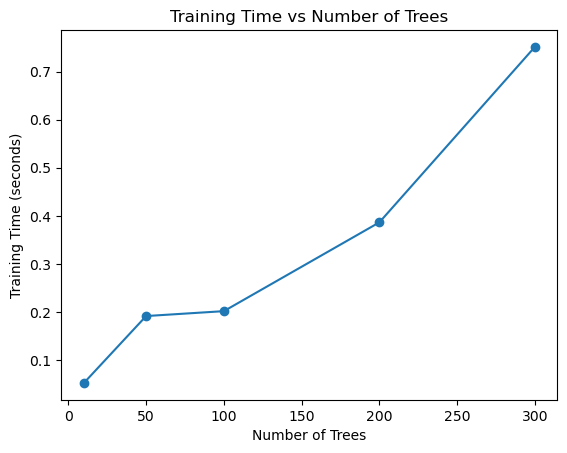

In [16]:
import matplotlib.pyplot as plt
import time
from sklearn.ensemble import RandomForestClassifier

tree_counts = [10, 50, 100, 200, 300]
times = []

for n in tree_counts:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    
    times.append(end - start)


plt.plot(tree_counts, times, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time vs Number of Trees")

plt.show()

In [22]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    "SVM": SVC(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=5)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"\n{name} MODEL")
    print("Accuracy:", acc * 100)
    print(confusion_matrix(y_test, y_pred))


SVM MODEL
Accuracy: 79.33333333333333
[[ 42   0   8   5]
 [  0   0   3   0]
 [ 23   0 159  21]
 [  2   0   0  37]]

Logistic Regression MODEL
Accuracy: 78.33333333333333
[[ 25   0  27   3]
 [  0   1   2   0]
 [ 15   0 181   7]
 [  7   0   4  28]]

KNN MODEL
Accuracy: 87.66666666666667
[[ 50   0   1   4]
 [  0   0   3   0]
 [ 16   0 181   6]
 [  0   0   7  32]]

Decision Tree MODEL
Accuracy: 100.0
[[ 55   0   0   0]
 [  0   3   0   0]
 [  0   0 203   0]
 [  0   0   0  39]]


C:\Users\ipsai\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


model1 = LogisticRegression(max_iter=1000)
model2 = DecisionTreeClassifier(max_depth=5)
model3 = SVC(probability=True)


hybrid_model = VotingClassifier(
    estimators=[
        ('lr', model1),
        ('dt', model2),
        ('svm', model3)
    ],
    voting='soft'   
)

hybrid_model.fit(X_train, y_train)


y_pred = hybrid_model.predict(X_test)


acc = accuracy_score(y_test, y_pred)

print("\n HYBRID MODEL (Voting Classifier)")
print("Accuracy:", acc * 100)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

C:\Users\ipsai\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



 HYBRID MODEL (Voting Classifier)
Accuracy: 97.66666666666667

Confusion Matrix:
[[ 53   0   0   2]
 [  0   1   2   0]
 [  0   0 200   3]
 [  0   0   0  39]]


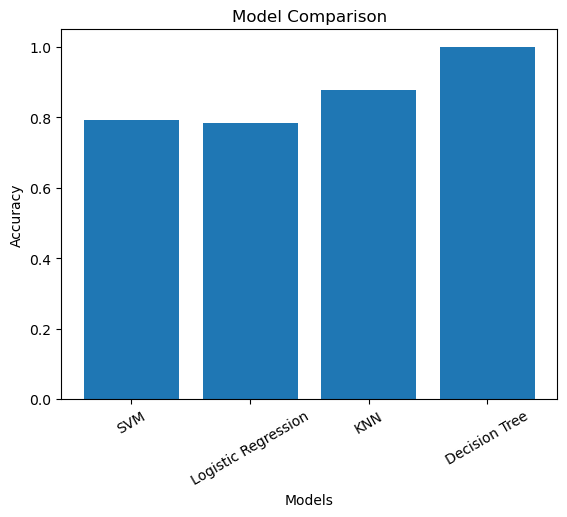

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

model_names = []
accuracies = []

# Loop through trained models
for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    model_names.append(name)
    accuracies.append(acc)

# Plot
plt.figure()

plt.bar(model_names, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.xticks(rotation=30)

plt.show()